In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (283085, 19)
Test shape: (177063, 19)


In [3]:
number_columns = [
    "high", "low", "momentum_index", "beta_indicator", "risk_premium",
    "volatility_factor", "technical_score", "oscillator_value",
    "liquidity_ratio", "open", "quant_index", "trend_strength",
    "market_sentiment", "volume", "alpha_signal",
]

In [4]:
for col in number_columns:
    train[col] = train[col].replace(0, np.nan)
    test[col] = test[col].replace(0, np.nan)

medians = train[number_columns].median()

train[number_columns] = train[number_columns].fillna(medians)
test[number_columns] = test[number_columns].fillna(medians)

In [5]:
train = train[train["close"].notna() & (train["close"] != 0)]
test = test[test["close"].notna() & (test["close"] != 0)]
print("Train rows after cleaning:", train.shape[0])
print("Test rows after cleaning:", test.shape[0])

Train rows after cleaning: 280078
Test rows after cleaning: 176495


In [6]:
symbol_columns = []
for value in train["symbols"].unique():
    name = "symbol_" + value
    train[name] = (train["symbols"] == value).astype(int)
    test[name] = (test["symbols"] == value).astype(int)
    symbol_columns.append(name)

feature_columns = number_columns + symbol_columns

In [7]:
X_train = train[feature_columns].to_numpy(dtype=float)
y_train = train["close"].to_numpy(dtype=float)

X_test = test[feature_columns].to_numpy(dtype=float)
y_test = test["close"].to_numpy(dtype=float)

In [8]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

# NOTE: we do NOT scale y (close). It is the value we predict,
# so it stays in real prices.

In [9]:
def predict(X, w):
    return X @ w


def cost(X, y, w):
    m = len(y)
    errors = predict(X, w) - y
    return (errors ** 2).sum() / m


def r2_score(y_real, y_pred):
    ss_res = ((y_real - y_pred) ** 2).sum()
    ss_tot = ((y_real - y_real.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

In [10]:
learning_rate = 0.1
epochs = 300

w = np.zeros(X_train.shape[1])
m = len(y_train)

train_costs = []
test_costs = []
train_accs = []
test_accs = []

for epoch in range(1, epochs + 1):
    # one step of gradient descent
    errors = predict(X_train, w) - y_train
    gradient = 2 * (X_train.T @ errors) / m
    w = w - learning_rate * gradient

    # save the cost
    train_costs.append(cost(X_train, y_train, w))
    test_costs.append(cost(X_test, y_test, w))

    # save the accuracy (predictions are already in real prices)
    train_pred = predict(X_train, w)
    test_pred = predict(X_test, w)
    train_accs.append(r2_score(y_train, train_pred) * 100)
    test_accs.append(r2_score(y_test, test_pred) * 100)

    print(f"Epoch {epoch:3d} | cost: {train_costs[-1]:.5f} | "
          f"train accuracy: {train_accs[-1]:.2f}% | "
          f"test accuracy: {test_accs[-1]:.2f}%")

Epoch   1 | cost: 3594.10697 | train accuracy: 36.33% | test accuracy: 22.31%
Epoch   2 | cost: 2417.23914 | train accuracy: 57.18% | test accuracy: 42.44%
Epoch   3 | cost: 1724.30947 | train accuracy: 69.46% | test accuracy: 52.61%
Epoch   4 | cost: 1279.26240 | train accuracy: 77.34% | test accuracy: 59.56%
Epoch   5 | cost: 988.90378 | train accuracy: 82.48% | test accuracy: 64.16%
Epoch   6 | cost: 796.80471 | train accuracy: 85.89% | test accuracy: 67.31%
Epoch   7 | cost: 667.60039 | train accuracy: 88.17% | test accuracy: 69.55%
Epoch   8 | cost: 578.88099 | train accuracy: 89.75% | test accuracy: 71.20%
Epoch   9 | cost: 516.35907 | train accuracy: 90.85% | test accuracy: 72.50%


Epoch  10 | cost: 470.89141 | train accuracy: 91.66% | test accuracy: 73.56%
Epoch  11 | cost: 436.61133 | train accuracy: 92.27% | test accuracy: 74.49%
Epoch  12 | cost: 409.74588 | train accuracy: 92.74% | test accuracy: 75.32%
Epoch  13 | cost: 387.86278 | train accuracy: 93.13% | test accuracy: 76.09%
Epoch  14 | cost: 369.38943 | train accuracy: 93.46% | test accuracy: 76.82%
Epoch  15 | cost: 353.30518 | train accuracy: 93.74% | test accuracy: 77.53%
Epoch  16 | cost: 338.94417 | train accuracy: 94.00% | test accuracy: 78.21%
Epoch  17 | cost: 325.86900 | train accuracy: 94.23% | test accuracy: 78.87%
Epoch  18 | cost: 313.78955 | train accuracy: 94.44% | test accuracy: 79.52%
Epoch  19 | cost: 302.51095 | train accuracy: 94.64% | test accuracy: 80.15%


Epoch  20 | cost: 291.90003 | train accuracy: 94.83% | test accuracy: 80.76%
Epoch  21 | cost: 281.86383 | train accuracy: 95.01% | test accuracy: 81.36%
Epoch  22 | cost: 272.33568 | train accuracy: 95.18% | test accuracy: 81.94%
Epoch  23 | cost: 263.26622 | train accuracy: 95.34% | test accuracy: 82.50%
Epoch  24 | cost: 254.61764 | train accuracy: 95.49% | test accuracy: 83.04%
Epoch  25 | cost: 246.35988 | train accuracy: 95.64% | test accuracy: 83.57%
Epoch  26 | cost: 238.46818 | train accuracy: 95.78% | test accuracy: 84.08%
Epoch  27 | cost: 230.92150 | train accuracy: 95.91% | test accuracy: 84.58%
Epoch  28 | cost: 223.70146 | train accuracy: 96.04% | test accuracy: 85.06%
Epoch  29 | cost: 216.79161 | train accuracy: 96.16% | test accuracy: 85.52%


Epoch  30 | cost: 210.17702 | train accuracy: 96.28% | test accuracy: 85.96%
Epoch  31 | cost: 203.84390 | train accuracy: 96.39% | test accuracy: 86.39%
Epoch  32 | cost: 197.77943 | train accuracy: 96.50% | test accuracy: 86.81%
Epoch  33 | cost: 191.97158 | train accuracy: 96.60% | test accuracy: 87.21%
Epoch  34 | cost: 186.40901 | train accuracy: 96.70% | test accuracy: 87.59%
Epoch  35 | cost: 181.08099 | train accuracy: 96.79% | test accuracy: 87.96%
Epoch  36 | cost: 175.97734 | train accuracy: 96.88% | test accuracy: 88.31%
Epoch  37 | cost: 171.08837 | train accuracy: 96.97% | test accuracy: 88.65%
Epoch  38 | cost: 166.40487 | train accuracy: 97.05% | test accuracy: 88.98%


Epoch  39 | cost: 161.91804 | train accuracy: 97.13% | test accuracy: 89.30%
Epoch  40 | cost: 157.61947 | train accuracy: 97.21% | test accuracy: 89.60%
Epoch  41 | cost: 153.50117 | train accuracy: 97.28% | test accuracy: 89.89%
Epoch  42 | cost: 149.55547 | train accuracy: 97.35% | test accuracy: 90.17%
Epoch  43 | cost: 145.77505 | train accuracy: 97.42% | test accuracy: 90.44%
Epoch  44 | cost: 142.15291 | train accuracy: 97.48% | test accuracy: 90.70%
Epoch  45 | cost: 138.68237 | train accuracy: 97.54% | test accuracy: 90.95%
Epoch  46 | cost: 135.35701 | train accuracy: 97.60% | test accuracy: 91.19%
Epoch  47 | cost: 132.17071 | train accuracy: 97.66% | test accuracy: 91.41%


...

Epoch 258 | cost: 58.80031 | train accuracy: 98.96% | test accuracy: 96.77%
Epoch 259 | cost: 58.79954 | train accuracy: 98.96% | test accuracy: 96.77%
Epoch 260 | cost: 58.79880 | train accuracy: 98.96% | test accuracy: 96.77%
Epoch 261 | cost: 58.79807 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 262 | cost: 58.79735 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 263 | cost: 58.79666 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 264 | cost: 58.79597 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 265 | cost: 58.79531 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 266 | cost: 58.79465 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 267 | cost: 58.79401 | train accuracy: 98.96% | test accuracy: 96.78%


Epoch 268 | cost: 58.79338 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 269 | cost: 58.79277 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 270 | cost: 58.79216 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 271 | cost: 58.79157 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 272 | cost: 58.79099 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 273 | cost: 58.79042 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 274 | cost: 58.78986 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 275 | cost: 58.78931 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 276 | cost: 58.78877 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 277 | cost: 58.78824 | train accuracy: 98.96% | test accuracy: 96.78%


Epoch 278 | cost: 58.78771 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 279 | cost: 58.78720 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 280 | cost: 58.78669 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 281 | cost: 58.78619 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 282 | cost: 58.78570 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 283 | cost: 58.78522 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 284 | cost: 58.78474 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 285 | cost: 58.78427 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 286 | cost: 58.78381 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 287 | cost: 58.78335 | train accuracy: 98.96% | test accuracy: 96.78%


Epoch 288 | cost: 58.78290 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 289 | cost: 58.78245 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 290 | cost: 58.78201 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 291 | cost: 58.78158 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 292 | cost: 58.78115 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 293 | cost: 58.78073 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 294 | cost: 58.78031 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 295 | cost: 58.77990 | train accuracy: 98.96% | test accuracy: 96.78%


Epoch 296 | cost: 58.77949 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 297 | cost: 58.77908 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 298 | cost: 58.77868 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 299 | cost: 58.77829 | train accuracy: 98.96% | test accuracy: 96.78%
Epoch 300 | cost: 58.77789 | train accuracy: 98.96% | test accuracy: 96.79%


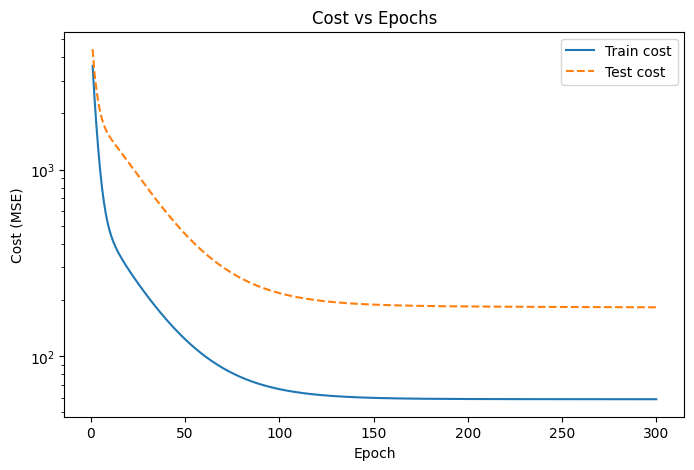

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_costs, label="Train cost")
plt.plot(range(1, epochs + 1), test_costs, label="Test cost", linestyle="--")
plt.title("Cost vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.yscale("log")
plt.legend()
plt.savefig("cost_plot.png", dpi=150)
plt.show()

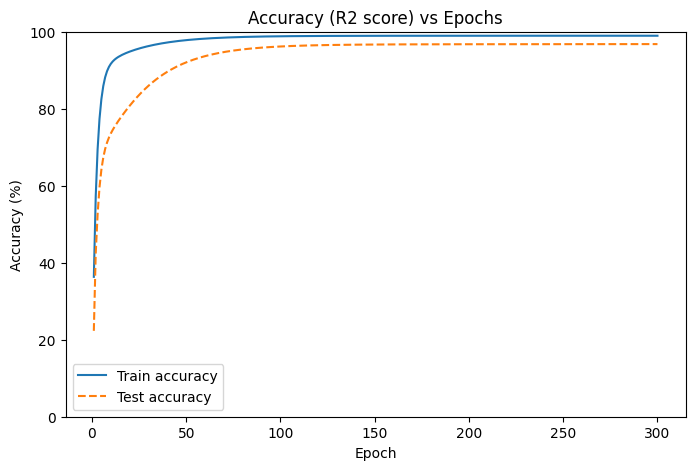

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accs, label="Train accuracy")
plt.plot(range(1, epochs + 1), test_accs, label="Test accuracy", linestyle="--")
plt.title("Accuracy (R2 score) vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
plt.savefig("accuracy_plot.png", dpi=150)
plt.show()

In [13]:
final_pred = predict(X_test, w)
mae = np.abs(y_test - final_pred).mean()
rmse = np.sqrt(((y_test - final_pred) ** 2).mean())

print("Final train accuracy (R2):", round(train_accs[-1], 2), "%")
print("Final test accuracy  (R2):", round(test_accs[-1], 2), "%")
print("Average error (MAE):", round(mae, 2))
print("RMSE:", round(rmse, 2))

Final train accuracy (R2): 98.96 %
Final test accuracy  (R2): 96.79 %
Average error (MAE): 10.36
RMSE: 13.52


In [14]:
results = pd.DataFrame({
    "Expected close": y_test,
    "Predicted close": final_pred,
})
results["Error"] = results["Predicted close"] - results["Expected close"]

print("Expected vs Predicted (first 20 rows of the test file):")
print(results.head(20).round(2).to_string())

results.to_csv("test_predictions.csv", index=False)
print("All", len(results), "test predictions saved to test_predictions.csv")

train_final_pred = predict(X_train, w)
print()
print("========== FINAL SUMMARY ==========")
print("Epochs trained:", epochs)
print("Learning rate:", learning_rate)
print("Train cost (MSE):", round(cost(X_train, y_train, w), 2))
print("Test cost (MSE): ", round(cost(X_test, y_test, w), 2))
print("Train accuracy (R2):", round(r2_score(y_train, train_final_pred) * 100, 2), "%")
print("Test accuracy (R2): ", round(r2_score(y_test, final_pred) * 100, 2), "%")
print("Test MAE: ", round(mae, 2))
print("Test RMSE:", round(rmse, 2))

Expected vs Predicted (first 20 rows of the test file):
    Expected close  Predicted close  Error
0            42.10            34.29  -7.81
1           102.64           119.16  16.52
2            46.15            55.46   9.31
3            51.86            66.48  14.62
4            40.79            31.19  -9.60
5            25.35            21.77  -3.58
6            22.58            10.65 -11.93
7            52.18            75.20  23.02
8            43.13            34.03  -9.10
9           104.22            94.05 -10.17
10          553.24           532.46 -20.78
11           43.28            15.68 -27.60
12           84.84           106.44  21.60
13           42.55            51.45   8.90
14           17.97            13.91  -4.06
15           58.77            72.64  13.87
16           78.76            80.22   1.46
17           52.76            67.03  14.27
18           99.89           111.77  11.88
19          151.10           130.92 -20.18


All 176495 test predictions saved to test_predictions.csv

========== FINAL SUMMARY ==========
Epochs trained: 300
Learning rate: 0.1
Train cost (MSE): 58.78
Test cost (MSE):  182.74
Train accuracy (R2): 98.96 %
Test accuracy (R2):  96.79 %
Test MAE:  10.36
Test RMSE: 13.52
